# Lecture 12: Bootstrap & ensemble methods

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import make_moons

# Sampling distribution vs bootstrap distribution

Most of the time, the sampling distribution is either unknowable (when working with real-world data) or analytically intractable.

So use Monte-Carlo estimates of the sampling distribution given known Data-Generating Process (DGP).

In [2]:
def make_regression(X, weights, scale=1, random_state=None):
    "Sample new responses for fixed covariates X."
    N, F = X.shape
    noise = np.random.RandomState(random_state).normal(scale=scale, size=N)
    y = X.dot(weights) + noise
    return y

## Sampling distribution

Many samples from true DGP, one estimate for each sample.

In [3]:
rng = np.random.RandomState(4)
X = rng.normal(size=(200, 5))
weights = np.array([-1, 0.5, 2, -0.1, 0.7])

parameter_of_interest = 0
est_lin, est_ridge = [], []
for _ in range(10_000): # generate many samples from true DGP
    y = make_regression(X, weights)

    # 1. Fit LinearRegression and Ridge
    # 2. Extract estimated `parameter_of_interest`
    ...
est_lin, est_ridge = map(np.array, (est_lin, est_ridge))

est_lin

array([-1.0721856 , -0.96236014, -0.9143033 , ..., -1.02419892,
       -0.95665388, -0.94689106], shape=(10000,))

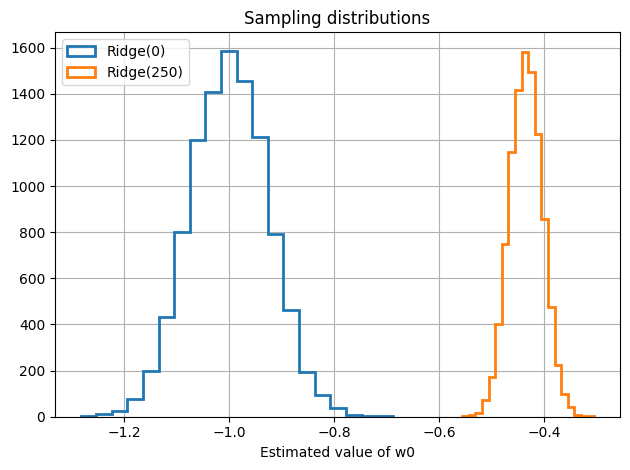

In [4]:
plt.hist(est_lin, histtype='step', bins=20, linewidth=2, label='Ridge(0)')
plt.hist(est_ridge, histtype='step', bins=20, linewidth=2, label='Ridge(250)')
plt.title('Sampling distributions')
plt.xlabel(f'Estimated value of w{parameter_of_interest}')
plt.legend(); plt.grid(); plt.tight_layout();

In [5]:
print('Bias Ridge(0)  :', (weights[parameter_of_interest] - est_lin).mean())
print('Bias Ridge(250):', (weights[parameter_of_interest] - est_ridge).mean())

print('Variance Ridge(0)  :', (weights[parameter_of_interest] - est_lin).var(ddof=1))
print('Variance Ridge(250):', (weights[parameter_of_interest] - est_ridge).var(ddof=1))

Bias Ridge(0)  : -0.0005130380342024672
Bias Ridge(250): -0.5650382940958674
Variance Ridge(0)  : 0.005385793302887715
Variance Ridge(250): 0.0009594798177066865


In this case, the Ridge estimator is _biased_, but has _lower variance_.

Monte-Carlo uses compute instead of math to derive (approximate!) properties of estimators.

## Bootstrap distribution

We only have _one sample_ (real life). Resample this sample and treat reamples as coming from the original DGP.

In [6]:
y = make_regression(X, weights, random_state=5)

est_lin_boot, est_ridge_boot = [], []
for _ in range(10_000): # generate many resamples from (X, y)
    X_boot = ...
    y_boot = ...
    
    what = LinearRegression().fit(X_boot, y_boot).coef_
    est_lin_boot.append(what[parameter_of_interest])
    what = Ridge(250).fit(X_boot, y_boot).coef_
    est_ridge_boot.append(what[parameter_of_interest])
est_lin_boot, est_ridge_boot = map(np.array, (est_lin_boot, est_ridge_boot))

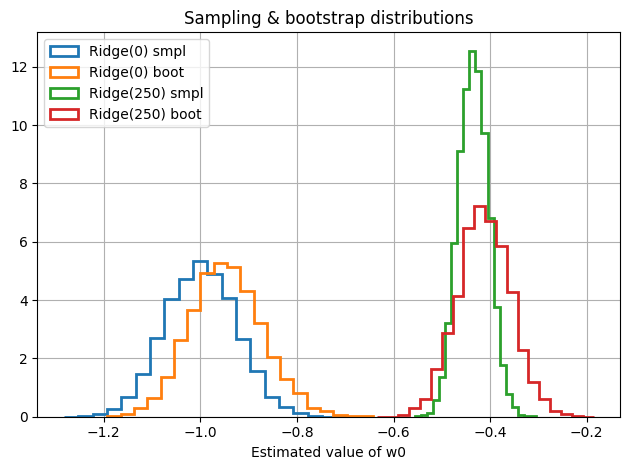

In [7]:
plt.hist(est_lin, histtype='step', bins=20, linewidth=2, density=True, label='Ridge(0) smpl')
plt.hist(est_lin_boot, histtype='step', bins=20, linewidth=2, density=True, label='Ridge(0) boot')
plt.hist(est_ridge, histtype='step', bins=20, linewidth=2, density=True, label='Ridge(250) smpl')
plt.hist(est_ridge_boot, histtype='step', bins=20, linewidth=2, density=True, label='Ridge(250) boot')
plt.title('Sampling & bootstrap distributions')
plt.xlabel(f'Estimated value of w{parameter_of_interest}')
plt.legend(); plt.grid(); plt.tight_layout();

The bootstrap distributions are different from the sampling distributions because of estimation/approximation error.

## Bootstrap confidence intervals

Verify $P(\hat\theta_l < \theta < \hat\theta_h) \approx 0.95$ using Monte-Carlo.

# Bagging can reduce variance of an estimator

Goal: estimate the scale $\sigma$ in $\mathcal N(0, \sigma)$.

Estimator:
$$
\hat\sigma = \sqrt{\pi/2} |x_1|
$$
Yes, use the _first_ observation of the sample.

- This estimator is unbiased: $\mathbb E \hat\sigma = \sigma$.
- It's _not_ consistent, because it doesn't depend on the number of observations $N$.
- But it can be used to prove a point.

In [8]:
def estimator(xs: np.ndarray):
    return np.sqrt(np.pi / 2) * abs(xs[0])

In [9]:
def estimator_bagg(estimator, sample: np.ndarray, nboot=50, random_state=None):
    N = len(sample)
    rng = np.random.RandomState(random_state)
    bootstrap_distribution = []
    for _ in range(nboot):
        bootstrap_distribution.append(...)
    return np.mean(bootstrap_distribution) # aggregate

In [10]:
sample = np.random.RandomState(6).normal(scale=0.4, size=100)
estimator(sample), estimator_bagg(estimator, sample, 500), estimator_bagg(estimator, sample, 500)

(np.float64(0.1563051543064258),
 np.float64(0.38015244307070417),
 np.float64(0.4087778480587319))

Simulate many datasets from the same DGP and plot the true sampling distributions of two estimators:
1. The original $\hat\sigma$.
2. The bagged $\hat\sigma$.

In [11]:
rng = np.random.RandomState(5)
estimand = 3
res_basic, res_bagg = [], []
for _ in range(10_000):
    dataset = rng.normal(scale=estimand, size=20)
    res_basic.append(estimator(dataset))
    res_bagg.append(
        estimator_bagg(estimator, dataset)
    )
res_basic, res_bagg = map(np.array, (res_basic, res_bagg))

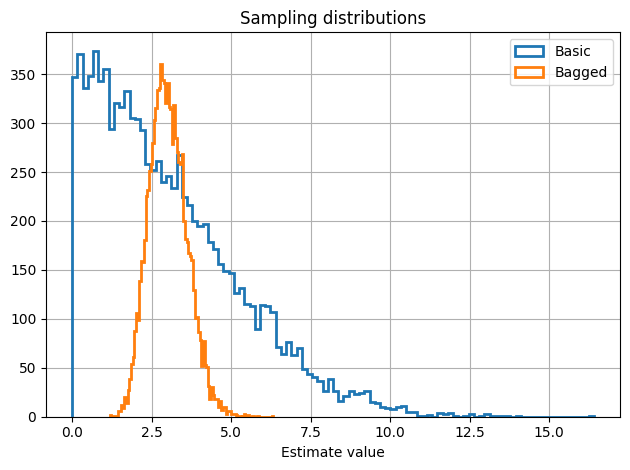

In [12]:
plt.hist(res_basic, histtype='step', bins=100, linewidth=2, label='Basic')
plt.hist(res_bagg, histtype='step', bins=100, linewidth=2, label='Bagged')
plt.title('Sampling distributions')
plt.xlabel('Estimate value')
plt.legend(); plt.grid(); plt.tight_layout();

In [13]:
{'basic var': res_basic.var(ddof=1), 'bagg var': res_bagg.var(ddof=1)}

{'basic var': np.float64(5.131987887784341),
 'bagg var': np.float64(0.35969505156415044)}

# Bagging & forests can improve generalization

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

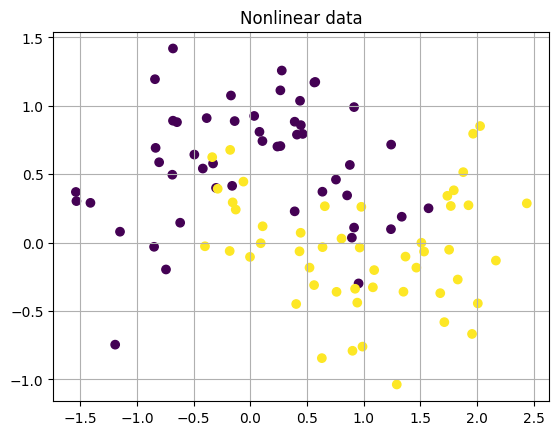

In [15]:
Xclf_train, yclf_train = make_moons(100, noise=0.3, random_state=5)
Xclf_test, yclf_test = make_moons(1000, noise=0.3, random_state=6)
plt.scatter(Xclf_train[:, 0], Xclf_train[:, 1], c=yclf_train)
plt.title('Nonlinear data')
plt.grid();

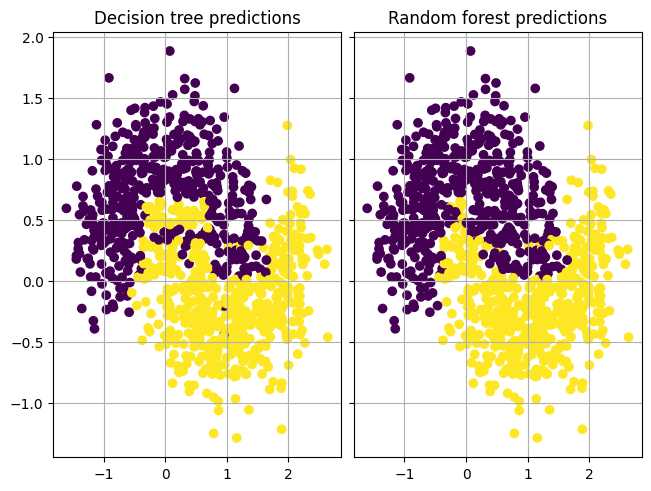

In [16]:
yhat_tree = DecisionTreeClassifier().fit(Xclf_train, yclf_train).predict(Xclf_test)
yhat_forest = RandomForestClassifier(
    n_estimators=200, max_features='sqrt'
).fit(Xclf_train, yclf_train).predict(Xclf_test)

f, (a1, a2) = plt.subplots(ncols=2, sharey=True, layout='constrained')
a1.scatter(Xclf_test[:, 0], Xclf_test[:, 1], c=yhat_tree)
a2.scatter(Xclf_test[:, 0], Xclf_test[:, 1], c=yhat_forest)
a1.grid(); a1.set_title('Decision tree predictions')
a2.grid(); a2.set_title('Random forest predictions')
f;

In [17]:
accuracy_score(yclf_test, yhat_tree), accuracy_score(yclf_test, yhat_forest)

(0.875, 0.903)